# **Import Libraries**

In [2]:
import re
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

# **Data Understanding**

In [3]:
df_kota = pd.read_csv('datasets/kota_final.csv')
df_provinsi = pd.read_csv('datasets/provinsi_final.csv')
df_nasional = pd.read_csv('datasets/nasional_final.csv')

In [4]:
df_kota.head()

,tahun,provinsi,kota_kabupaten,stunting_prevalence,life_expectancy_at_birth,hdi
0,2013,Aceh,Aceh Barat,NaN,67.30,66.86
1,2014,Aceh,Aceh Barat,NaN,67.33,67.31
2,2015,Aceh,Aceh Barat,NaN,67.49,68.41
3,2016,Aceh,Aceh Barat,NaN,67.56,69.26
4,2017,Aceh,Aceh Barat,NaN,67.62,70.20


In [5]:
df_provinsi.head()

,tahun,provinsi,stunting_prevalence,life_expectancy_at_birth,hdi
0,2013,Aceh,NaN,69.31,68.3
1,2014,Aceh,NaN,69.35,68.81
2,2015,Aceh,NaN,69.5,69.45
3,2016,Aceh,NaN,69.51,70
4,2017,Aceh,NaN,69.52,70.6


In [6]:
df_nasional.head()

,tahun,stunting_prevalence,life_expectancy_at_birth,hdi
0,2013,37.2,70.40,68.31
1,2014,37.0,70.59,68.90
2,2015,29.0,70.78,69.55
3,2016,27.5,70.90,70.18
4,2017,29.6,71.06,70.81


### Dataset 1 – Nasional

**Deskripsi singkat**  
Dataset nasional berisi data agregat Indonesia secara keseluruhan pada periode 2013–2024. Data ini memberikan gambaran makro mengenai prevalensi stunting, harapan hidup, dan indeks pembangunan manusia.

**Penjelasan kolom:**
- `tahun`: Tahun pengamatan.  
- `stunting_prevalence`: Persentase prevalensi stunting nasional (%).  
- `life_expectancy_at_birth`: Harapan hidup saat lahir (tahun).  
- `hdi`: Indeks Pembangunan Manusia (0–100).  


### Dataset 2 – Provinsi

**Deskripsi singkat**  
Dataset provinsi berisi data indikator pembangunan manusia dan kesehatan pada tingkat 34 provinsi di Indonesia. Data mencakup beberapa tahun, dengan variasi kelengkapan antar provinsi.

**Penjelasan kolom:**
- `tahun`: Tahun pengamatan.  
- `provinsi`: Nama provinsi.  
- `stunting_prevalence`: Persentase prevalensi stunting di provinsi tersebut.  
- `life_expectancy_at_birth`: Harapan hidup saat lahir di provinsi tersebut (tahun).  
- `hdi`: Indeks Pembangunan Manusia di provinsi tersebut.  


### Dataset 3 – Kota/Kabupaten

**Deskripsi singkat**  
Dataset kota/kabupaten berisi data detail indikator pembangunan manusia dan kesehatan di tingkat kota/kabupaten. Dataset ini paling granular, namun banyak nilai kosong terutama pada prevalensi stunting.

**Penjelasan kolom:**
- `tahun`: Tahun pengamatan.  
- `provinsi`: Nama provinsi induk.  
- `kota_kabupaten`: Nama kota atau kabupaten.  
- `stunting_prevalence`: Persentase prevalensi stunting (%).  
- `life_expectancy_at_birth`: Harapan hidup saat lahir (tahun).  
- `hdi`: Indeks Pembangunan Manusia kota/kabupaten.  


In [7]:
df_kota.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6303 entries, 0 to 6302
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tahun                     6303 non-null   int64  
 1   provinsi                  6303 non-null   object 
 2   kota_kabupaten            6303 non-null   object 
 3   stunting_prevalence       2525 non-null   float64
 4   life_expectancy_at_birth  6300 non-null   float64
 5   hdi                       6300 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 295.6+ KB


In [8]:
df_provinsi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   tahun                     468 non-null    int64 
 1   provinsi                  468 non-null    object
 2   stunting_prevalence       216 non-null    object
 3   life_expectancy_at_birth  468 non-null    object
 4   hdi                       468 non-null    object
dtypes: int64(1), object(4)
memory usage: 18.4+ KB


In [9]:
# Bersihkan nilai numerik yang disimpan sebagai string
for col in ["stunting_prevalence", "life_expectancy_at_birth", "hdi"]:
    df_provinsi[col] = (
        df_provinsi[col]
        .astype(str)                    # ubah ke string dulu
        .str.replace(",", ".", regex=False)  # ganti koma dengan titik (desimal)
        .str.replace("-", "", regex=False)   # hapus tanda strip jika ada
        .str.strip()                    # hapus spasi
    )
    df_provinsi[col] = pd.to_numeric(df_provinsi[col], errors="coerce")

# Ubah tahun jadi integer
df_provinsi["tahun"] = df_provinsi["tahun"].astype("Int64")


In [10]:
df_provinsi.describe()

,tahun,stunting_prevalence,life_expectancy_at_birth,hdi
count,468.0,216.000000,424.000000,432.000000
mean,2018.5,25.016204,69.735000,70.143750
std,3.455747,6.519061,2.609426,4.559839
min,2013.0,7.200000,63.320000,51.700000
25%,2015.75,20.575000,67.927500,67.867500
50%,2018.5,24.850000,69.855000,70.255000
75%,2021.25,29.122500,71.372500,72.537500
max,2024.0,43.820000,75.220000,83.080000


In [11]:
df_nasional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tahun                     12 non-null     int64  
 1   stunting_prevalence       12 non-null     float64
 2   life_expectancy_at_birth  12 non-null     float64
 3   hdi                       12 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 516.0 bytes


In [12]:
df_kota.describe()

,tahun,stunting_prevalence,life_expectancy_at_birth,hdi
count,6303.000000,2525.000000,6300.000000,6300.000000
mean,2018.570681,25.022384,69.342268,68.971419
std,3.457597,8.740324,3.588817,6.804048
min,2013.000000,4.100000,53.540000,24.420000
25%,2016.000000,18.900000,67.120000,65.530000
50%,2019.000000,24.500000,69.620000,68.910000
75%,2022.000000,30.100000,71.820000,72.560000
max,2024.000000,65.990000,78.260000,88.770000


In [13]:
df_provinsi.describe()

,tahun,stunting_prevalence,life_expectancy_at_birth,hdi
count,468.0,216.000000,424.000000,432.000000
mean,2018.5,25.016204,69.735000,70.143750
std,3.455747,6.519061,2.609426,4.559839
min,2013.0,7.200000,63.320000,51.700000
25%,2015.75,20.575000,67.927500,67.867500
50%,2018.5,24.850000,69.855000,70.255000
75%,2021.25,29.122500,71.372500,72.537500
max,2024.0,43.820000,75.220000,83.080000


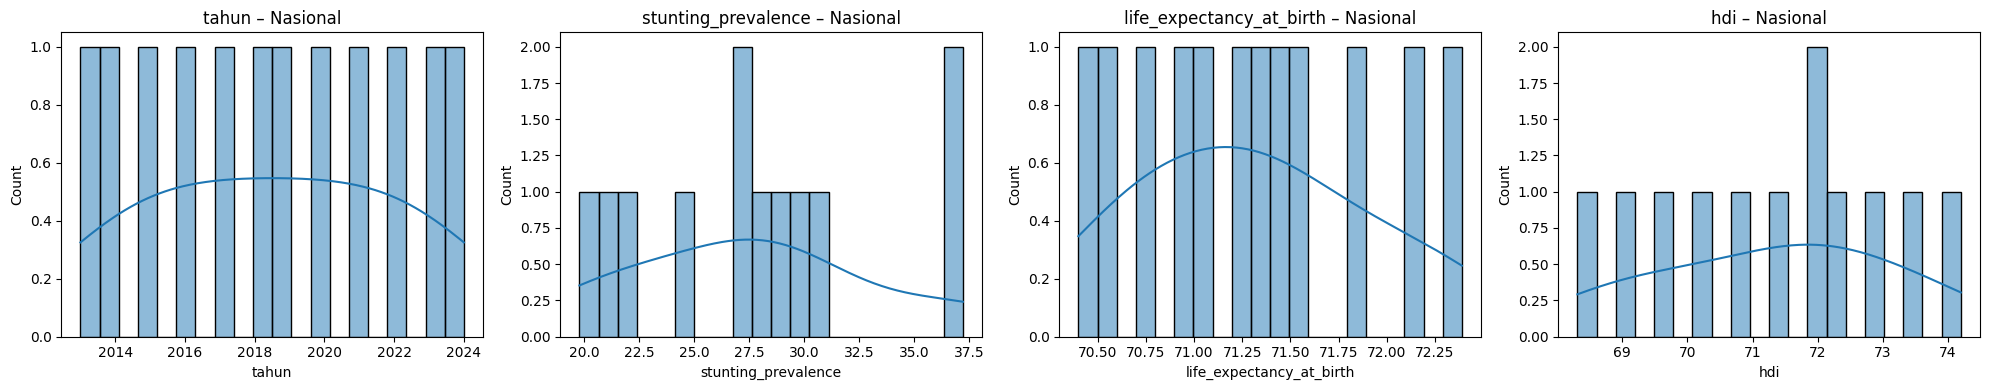

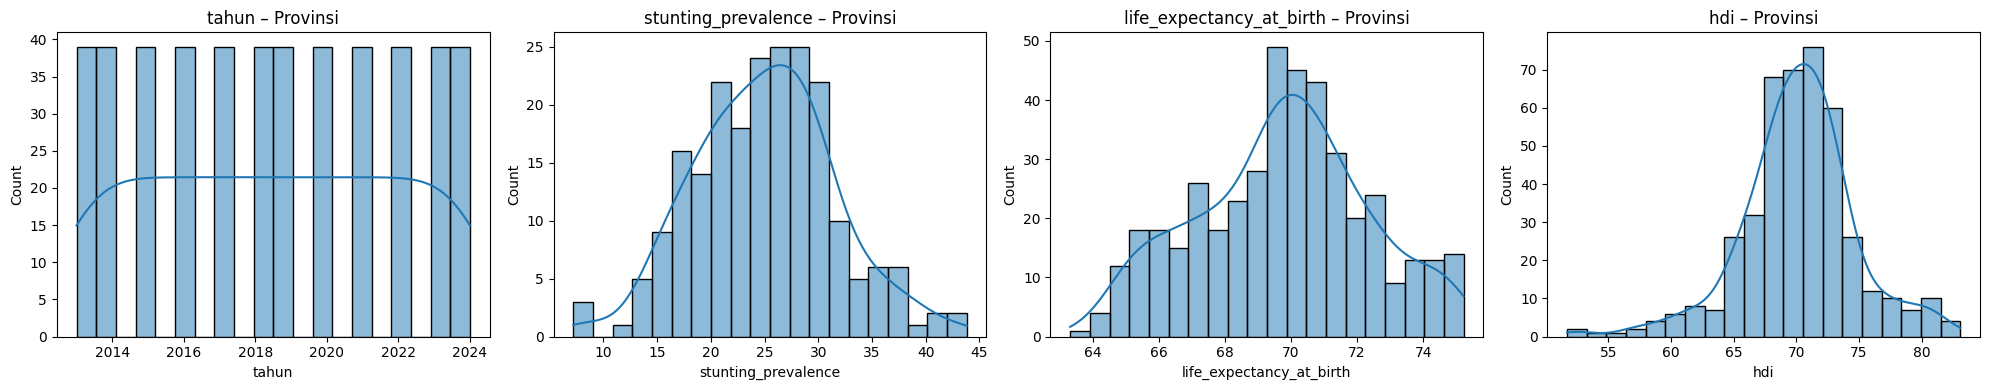

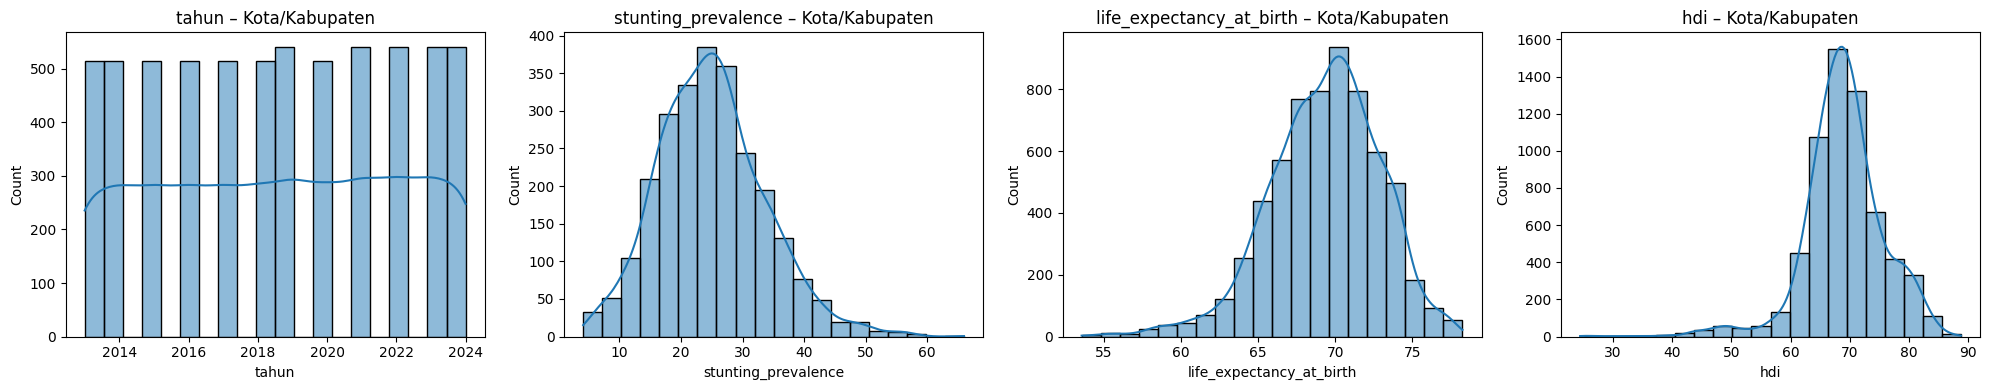

In [14]:
def plot_distributions(df, nama_dataset):
    num_cols = df.select_dtypes(include=["number"]).columns
    n = len(num_cols)
    if n == 0:
        print(f"Tidak ada kolom numerik pada {nama_dataset}")
        return
    
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]  # supaya bisa diiterasi
    
    for ax, col in zip(axes, num_cols):
        sns.histplot(df[col].dropna(), bins=20, kde=True, ax=ax)
        ax.set_title(f"{col} – {nama_dataset}")
        ax.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

# Cetak distribusi tiap dataset
plot_distributions(df_nasional, "Nasional")
plot_distributions(df_provinsi, "Provinsi")
plot_distributions(df_kota, "Kota/Kabupaten")

# **Data Cleaning**

In [15]:
df_kota.isna().sum()

tahun                          0
provinsi                       0
kota_kabupaten                 0
stunting_prevalence         3778
life_expectancy_at_birth       3
hdi                            3
dtype: int64

In [16]:
df_provinsi.isna().sum()

tahun                         0
provinsi                      0
stunting_prevalence         252
life_expectancy_at_birth     44
hdi                          36
dtype: int64

In [17]:
df_nasional.isna().sum()

tahun                       0
stunting_prevalence         0
life_expectancy_at_birth    0
hdi                         0
dtype: int64

Null value tidak di drop, karena data pada tahun itu memang tidak tersedia.

In [18]:
df_nasional.duplicated().sum()

np.int64(0)

In [19]:
df_provinsi.duplicated().sum()

np.int64(0)

In [20]:
df_kota.duplicated().sum()

np.int64(134)

In [21]:
# Cek apakah ada baris duplikat (berdasarkan semua kolom)
duplicates = df_kota[df_kota.duplicated()]

print("Jumlah baris duplikat:", len(duplicates))
print(duplicates)

# Jika ingin cek berdasarkan kolom tertentu (misalnya tahun + provinsi saja)
duplicates_subset = df_kota[df_kota.duplicated(subset=["tahun", "provinsi"])]
print("Jumlah duplikat berdasarkan tahun+provinsi:", len(duplicates_subset))
print(duplicates_subset)

Jumlah baris duplikat: 134
      tahun        provinsi kota_kabupaten  stunting_prevalence  \
463    2019          Banten         Serang                39.43   
466    2021          Banten         Serang                23.40   
468    2022          Banten         Serang                26.40   
470    2023          Banten         Serang                23.90   
472    2024          Banten         Serang                20.20   
...     ...             ...            ...                  ...   
5669   2019  Sumatera Barat          Solok                35.45   
5672   2021  Sumatera Barat          Solok                18.50   
5674   2022  Sumatera Barat          Solok                24.20   
5676   2023  Sumatera Barat          Solok                25.40   
5678   2024  Sumatera Barat          Solok                29.50   

      life_expectancy_at_birth    hdi  
463                      64.47  66.38  
466                      64.76  66.82  
468                      65.18  67.75  
470     

In [22]:
df_kota_cleaned = df_kota.drop_duplicates()
df_kota_cleaned.duplicated().sum()

np.int64(0)

# **EDA**

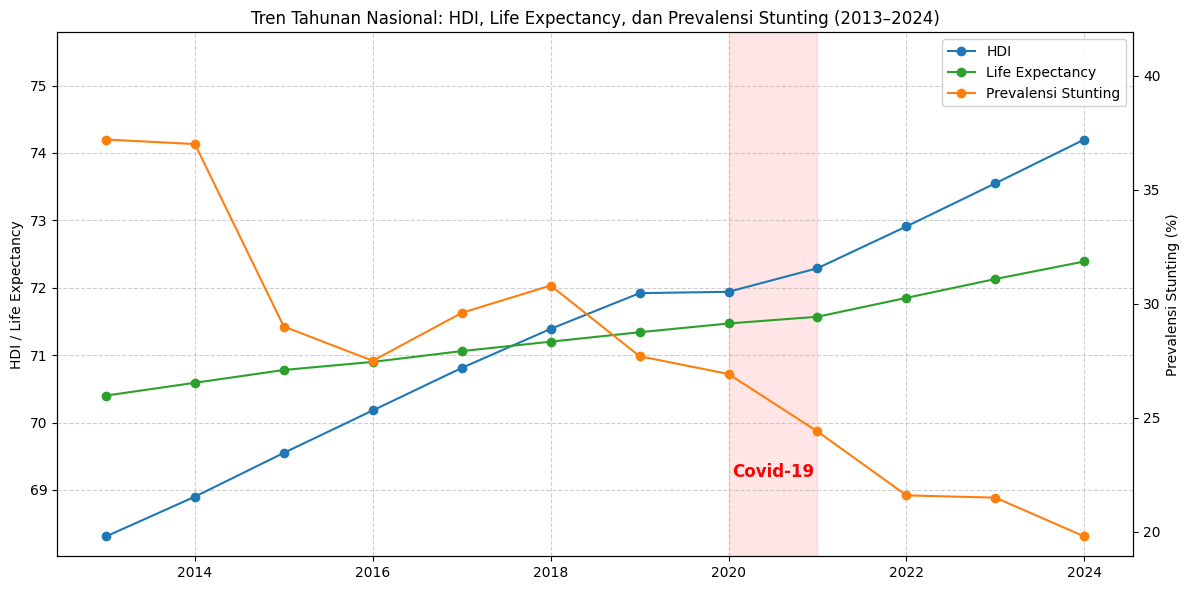

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Plot HDI dan Life Expectancy (sumbu kiri)
ax1.plot(df_nasional["tahun"], df_nasional["hdi"], marker="o", color="tab:blue", label="HDI")
ax1.plot(df_nasional["tahun"], df_nasional["life_expectancy_at_birth"], marker="o", color="tab:green", label="Life Expectancy")
ax1.set_ylabel("HDI / Life Expectancy")

# Plot Prevalensi Stunting (sumbu kanan)
ax2 = ax1.twinx()
ax2.plot(df_nasional["tahun"], df_nasional["stunting_prevalence"], marker="o", color="tab:orange", label="Prevalensi Stunting")
ax2.set_ylabel("Prevalensi Stunting (%)")

# === Tambah ruang di Y ===
ymin1, ymax1 = ax1.get_ylim()
ax1.set_ylim(ymin1, ymax1 + (ymax1 - ymin1)*0.2)  # tambah 20% ruang di atas

ymin2, ymax2 = ax2.get_ylim()
ax2.set_ylim(ymin2, ymax2 + (ymax2 - ymin2)*0.2)  # sama untuk axis kanan

# Highlight periode Covid-19 (2020-2021)
ax1.axvspan(2020, 2021, color="red", alpha=0.1)
mid_x = 2020.5
mid_y = df_nasional["hdi"].min() + (df_nasional["hdi"].max()-df_nasional["hdi"].min())*0.15
ax1.text(mid_x, mid_y, "Covid-19", color="red", fontsize=12, ha="center", fontweight="bold")

# Tambah grid & judul
ax1.set_title("Tren Tahunan Nasional: HDI, Life Expectancy, dan Prevalensi Stunting (2013–2024)")
ax1.grid(True, linestyle="--", alpha=0.6)

# Gabungkan legend dari kedua axis & taruh di pojok kanan atas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", bbox_to_anchor=(1, 1), borderaxespad=0.5,
           frameon=True, facecolor="white", framealpha=0.9)

plt.tight_layout()
plt.show()


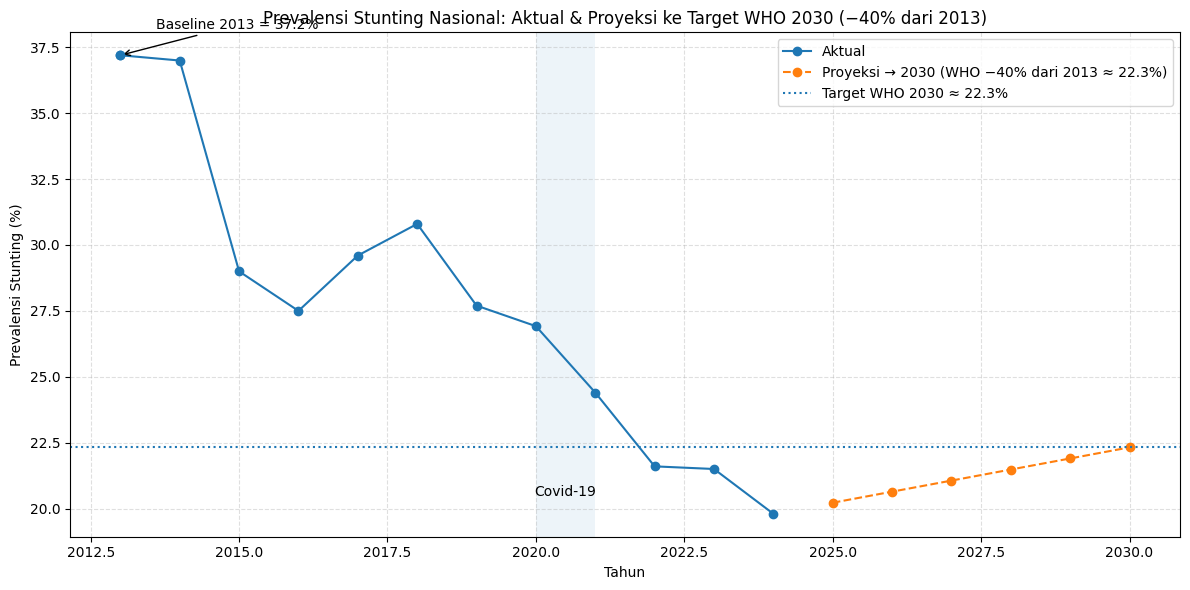

Baseline 2013 = 37.2% → Target WHO 2030 ≈ 22.3%
Dari 2024 = 19.8% ke 2030 ≈ 22.3%
Perlu penurunan rata-rata 0.42 poin persentase per tahun.


In [ ]:
# Bersihkan angka (toleransi koma desimal); BIARKAN 'tahun' di df_nasional tetap object
df_ = df_nasional.copy()
df_["stunting_prevalence"] = pd.to_numeric(
    df_["stunting_prevalence"].astype(str).str.replace(",", ".", regex=False).str.strip(),
    errors="coerce"
)
year_num = pd.to_numeric(df_["tahun"], errors="coerce")

actual = (
    df_.assign(_year=year_num)
       .dropna(subset=["_year","stunting_prevalence"])
       .sort_values("_year")
       .reset_index(drop=True)
)

if actual.empty:
    raise ValueError("Tidak ada baris valid untuk tahun & stunting_prevalence.")

# ==== TARGET RESMI WHO 2030 (global prevalence ≈ 13.5%) ====
WHO_2030_TARGET_PREV = 13.5  # dari dokumen WHO/UNICEF ekstensi 2030

# ==== OPSIONAL: baseline 2013 → 'target 40% dari 2013' (BUKAN target WHO 2030) ====
use_alt_40pct_from_2013 = False  # set True jika ingin menghitung target alternatif non-resmi ini
if use_alt_40pct_from_2013:
    if (actual["_year"] == 2013).any():
        base2013 = float(actual.loc[actual["_year"] == 2013, "stunting_prevalence"].iloc[0])
        ALT_TARGET_2030 = base2013 * 0.60  # 40% lebih rendah dari 2013
    else:
        raise ValueError("Tahun 2013 tidak ada di df_nasional untuk opsi 40% dari 2013.")
    target_label = f"Target 2030 (40%↓ dari 2013 ≈ {ALT_TARGET_2030:.1f}%)"
    target_value = ALT_TARGET_2030
else:
    target_label = f"Target WHO 2030 ≈ {WHO_2030_TARGET_PREV:.1f}%"
    target_value = WHO_2030_TARGET_PREV

# ==== Proyeksi linear dari titik aktual terakhir ke 2030 ====
TARGET_YEAR = 2030
last_year = int(actual["_year"].max())
last_val  = float(actual.loc[actual["_year"] == last_year, "stunting_prevalence"].iloc[0])

if TARGET_YEAR <= last_year:
    raise ValueError(f"Tahun target ({TARGET_YEAR}) harus > tahun terakhir data ({last_year}).")

years_proj = np.arange(last_year + 1, TARGET_YEAR + 1)
proj_vals  = last_val + (target_value - last_val) * ((years_proj - last_year) / (TARGET_YEAR - last_year))

# ==== Plot ====
fig, ax = plt.subplots(figsize=(12, 6))

# aktual
ax.plot(actual["_year"], actual["stunting_prevalence"], marker="o", label="Aktual")

# proyeksi → 2030
ax.plot(years_proj, proj_vals, linestyle="--", marker="o", label=f"Proyeksi → 2030 ({target_label})")

# garis target 2030
ax.axhline(y=target_value, linestyle=":", linewidth=1.5, label=target_label)

# anotasi baseline 2013 (kalau ada, biar konteks nasional terlihat)
if (actual["_year"] == 2013).any():
    base_2013 = float(actual.loc[actual["_year"] == 2013, "stunting_prevalence"].iloc[0])
    ax.scatter([2013], [base_2013], zorder=5)
    ax.annotate(f"Baseline 2013 = {base_2013:.1f}%",
                xy=(2013, base_2013),
                xytext=(2013+0.6, base_2013+1.0),
                arrowprops=dict(arrowstyle='->', lw=1))

# (opsional) sorot 2020–2021
ax.axvspan(2020, 2021, alpha=0.08)
ax.text(2020.5,
        ax.get_ylim()[0] + 0.08*(ax.get_ylim()[1]-ax.get_ylim()[0]),
        "Covid-19", ha="center", fontsize=10)

ax.set_title("Prevalensi Stunting Nasional: Aktual & Proyeksi ke 2030 (mengacu target WHO 2030)")
ax.set_xlabel("Tahun")
ax.set_ylabel("Prevalensi Stunting (%)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Info kebutuhan penurunan rata-rata per tahun
pp_per_year = (target_value - last_val) / (TARGET_YEAR - last_year)
print(f"Dari {last_year} = {last_val:.1f}% ke 2030 ≈ {target_value:.1f}% → perlu {pp_per_year:.2f} poin persentase/tahun.")

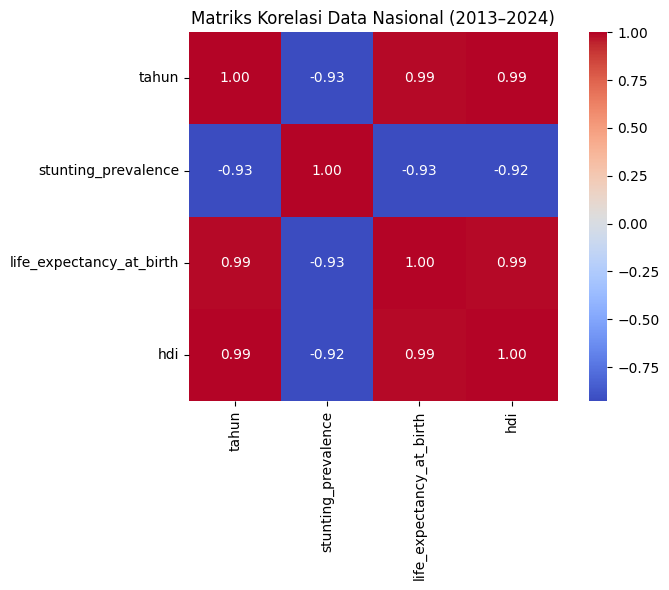

In [24]:
# Buat matriks korelasi
corr_matrix = df_nasional.corr(numeric_only=True)

# Plot heatmap korelasi
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True, square=True)
plt.title("Matriks Korelasi Data Nasional (2013–2024)")
plt.tight_layout()
plt.show()

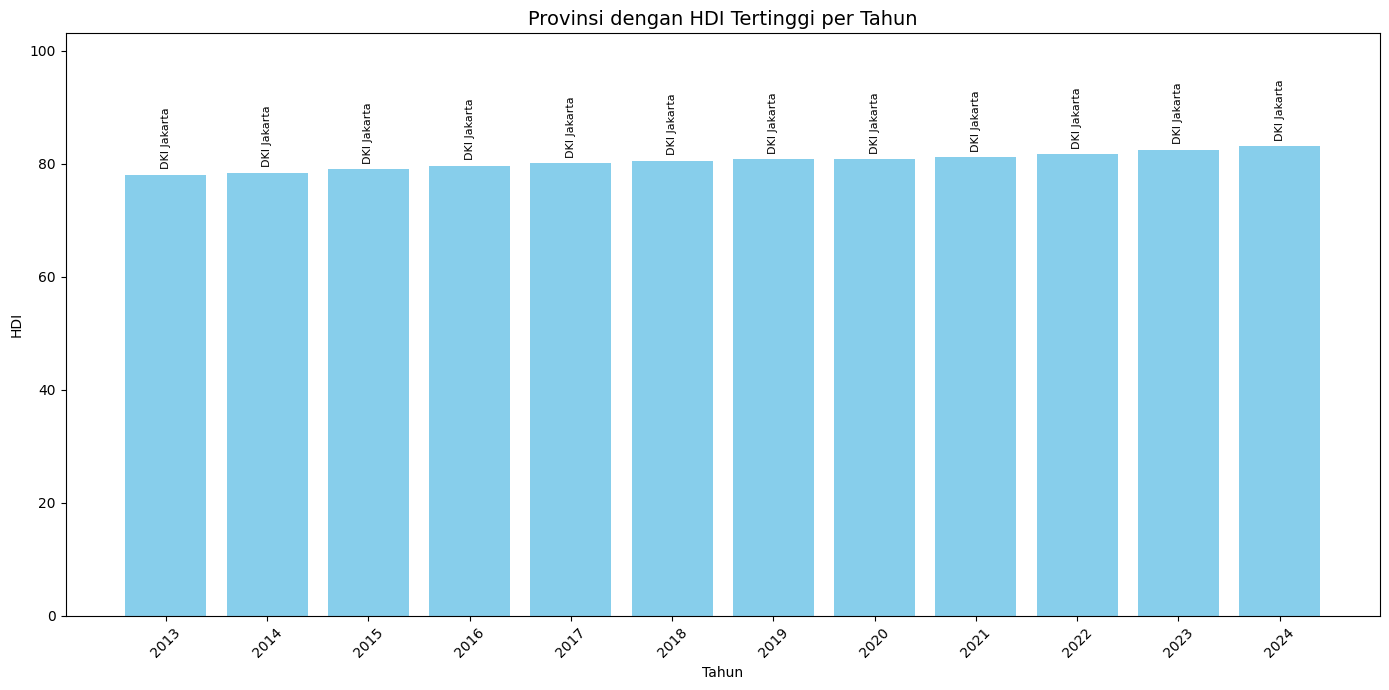

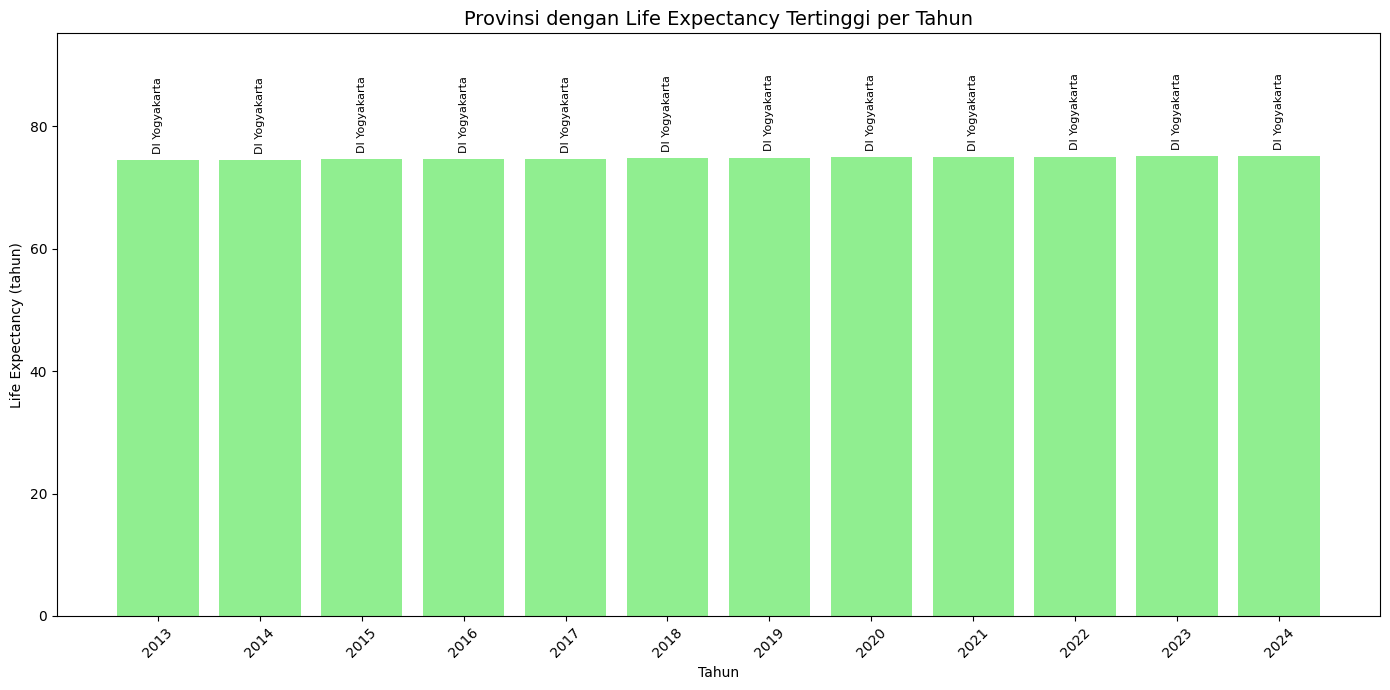

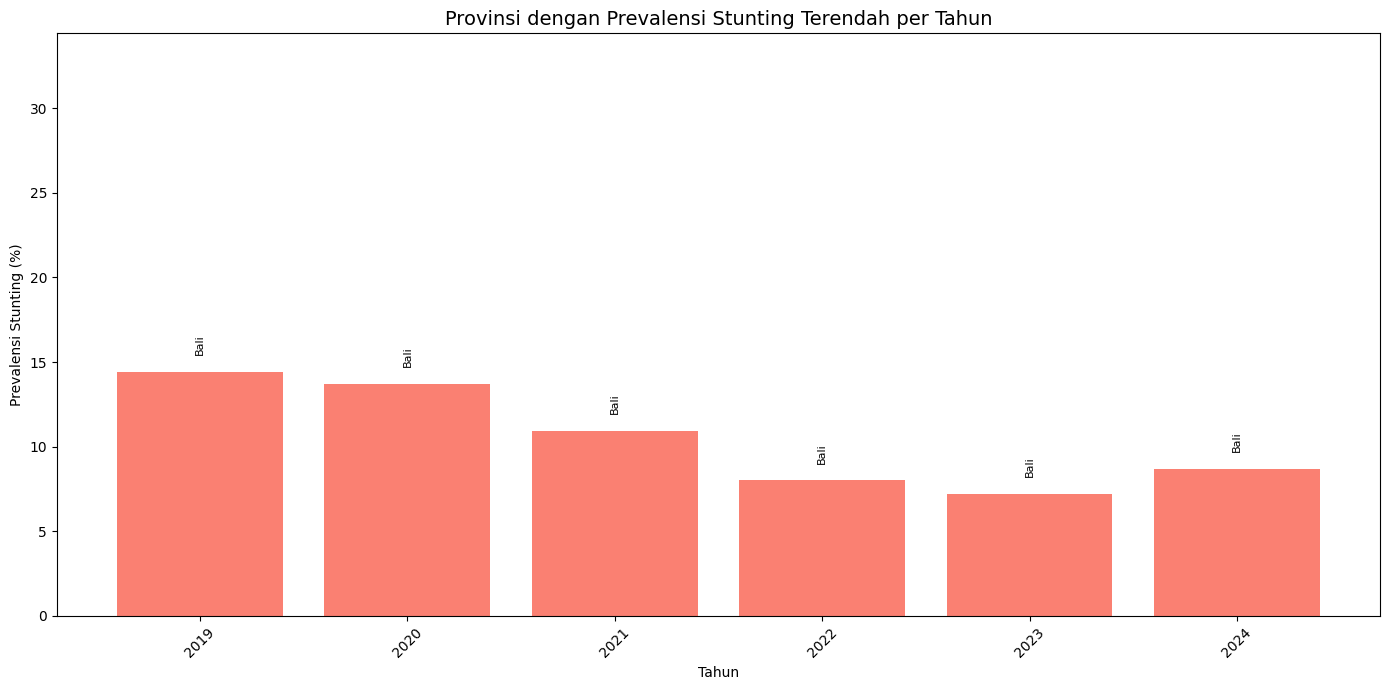

In [34]:
# === 1. Provinsi dengan HDI Tertinggi ===
df_max_hdi = df_provinsi.loc[df_provinsi.groupby("tahun")["hdi"].idxmax()]

plt.figure(figsize=(14,7))
bars = plt.bar(df_max_hdi["tahun"].astype(str), df_max_hdi["hdi"], color="skyblue")
for bar, prov in zip(bars, df_max_hdi["provinsi"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, prov,  # jarak teks lebih jauh
             ha="center", va="bottom", fontsize=8, rotation=90)
plt.ylim(0, df_max_hdi["hdi"].max() + 20)  # ruang Y lebih banyak
plt.title("Provinsi dengan HDI Tertinggi per Tahun", fontsize=14)
plt.xlabel("Tahun")
plt.ylabel("HDI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# === 2. Provinsi dengan Life Expectancy Tertinggi ===
df_max_le = df_provinsi.loc[df_provinsi.groupby("tahun")["life_expectancy_at_birth"].idxmax()]

plt.figure(figsize=(14,7))
bars = plt.bar(df_max_le["tahun"].astype(str), df_max_le["life_expectancy_at_birth"], color="lightgreen")
for bar, prov in zip(bars, df_max_le["provinsi"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, prov,
             ha="center", va="bottom", fontsize=8, rotation=90)
plt.ylim(0, df_max_le["life_expectancy_at_birth"].max() + 20)
plt.title("Provinsi dengan Life Expectancy Tertinggi per Tahun", fontsize=14)
plt.xlabel("Tahun")
plt.ylabel("Life Expectancy (tahun)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# === 3. Provinsi dengan Prevalensi Stunting Terendah ===
# === 3. Provinsi dengan Prevalensi Stunting Terendah ===
# Buang dulu baris dengan stunting NaN
df_st_valid = df_provinsi.dropna(subset=["stunting_prevalence"])

# Ambil provinsi dengan stunting prevalence TERENDAH tiap tahun
df_min_st = df_st_valid.loc[df_st_valid.groupby("tahun")["stunting_prevalence"].idxmin()]

plt.figure(figsize=(14,7))
bars = plt.bar(df_min_st["tahun"].astype(str), df_min_st["stunting_prevalence"], color="salmon")

# Tambahkan label provinsi di atas bar
for bar, prov in zip(bars, df_min_st["provinsi"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, prov,
             ha="center", va="bottom", fontsize=8, rotation=90)

# Tambahkan ruang lebih besar di Y
plt.ylim(0, df_min_st["stunting_prevalence"].max() + 20)

plt.title("Provinsi dengan Prevalensi Stunting Terendah per Tahun", fontsize=14)
plt.xlabel("Tahun")
plt.ylabel("Prevalensi Stunting (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
